In [126]:
import psycopg2
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap
from IPython.display import display

In [127]:
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group14',
    'password': 'blockd_2024group14_20'
}

In [128]:
conn = psycopg2.connect(**db_params)

In [129]:
cursor = conn.cursor()

In [130]:
plt.style.use('classic')

# ANWB - Safe Driving Dataset

## Event Overview

#### What are the most common types of events?

In [74]:
get_count = '''SELECT RTRIM(category) AS value, COUNT(*) as count
               FROM data_lake.safe_driving
               WHERE is_valid = TRUE
               GROUP BY RTRIM(category)
               ORDER BY count DESC
               '''

cursor.execute(get_count)
event_count = pd.DataFrame(cursor.fetchall())

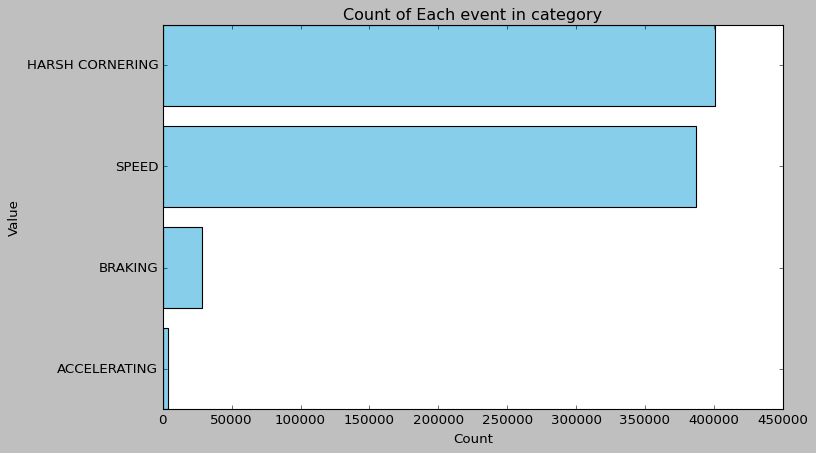

In [75]:
# Plot a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(event_count[0], event_count[1], color='skyblue')
plt.xlabel('Count')
plt.ylabel('Value')
plt.title('Count of Each event in category')
plt.gca().invert_yaxis()
plt.show()

#### How are events distributed over time ?

In [76]:
get_time_dist = '''SELECT event_start, RTRIM(category)
               FROM data_lake.safe_driving
               WHERE is_valid = TRUE'''

cursor.execute(get_time_dist)
time_dist = pd.DataFrame(cursor.fetchall())

time_dist['timestamp'] = pd.to_datetime(time_dist[0])

time_proc = pd.DataFrame()

time_proc['date'] = time_dist['timestamp'].dt.date
time_proc['minute'] = time_dist['timestamp'].dt.minute
time_proc['hour'] = time_dist['timestamp'].dt.hour
time_proc['day'] = time_dist['timestamp'].dt.day
time_proc['week'] = time_dist['timestamp'].dt.isocalendar().week
time_proc['month'] = time_dist['timestamp'].dt.month
time_proc['year'] = time_dist['timestamp'].dt.year

time_proc['category'] = time_dist[1]

print(time_proc.head())

         date  minute  hour  day  week  month  year         category
0  2020-08-25      53    17   25    35      8  2020            SPEED
1  2020-08-25      52     7   25    35      8  2020          BRAKING
2  2020-08-25      28    15   25    35      8  2020            SPEED
3  2020-08-25      59    15   25    35      8  2020  HARSH CORNERING
4  2020-08-25       4    17   25    35      8  2020  HARSH CORNERING


We will take a look at daily, hourly, weekly and monthly distribution:

In [77]:
daily_counts = time_proc.groupby('date').size().reset_index(name='count')

hourly_counts = time_proc.groupby('hour').size().reset_index(name='count')

weekly_counts = time_proc.groupby('week').size().reset_index(name='count')

monthly_counts = time_proc.groupby(['year', 'month']).size().reset_index(name='count')

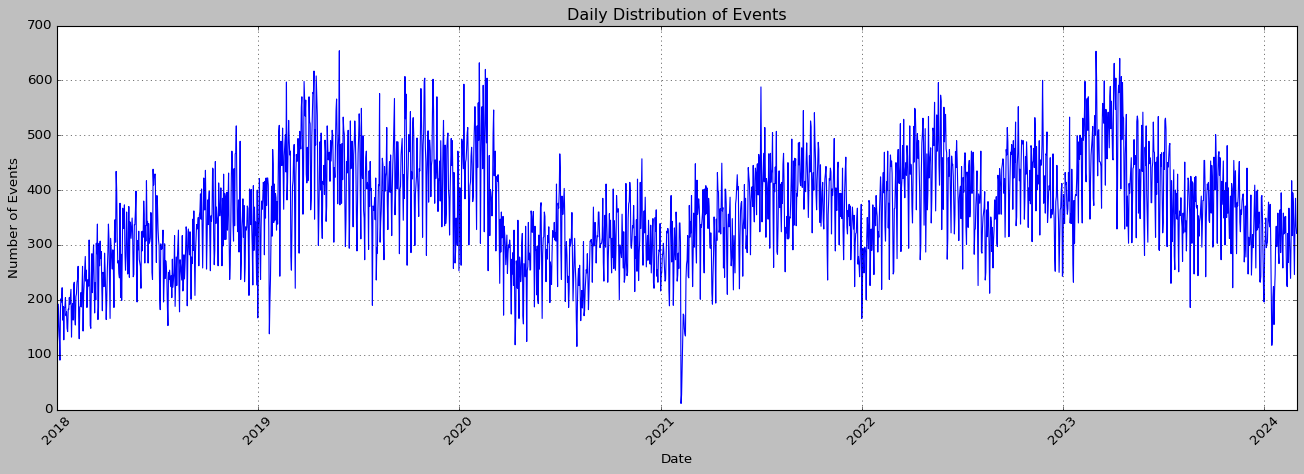

In [148]:
# Plot daily distribution
plt.figure(figsize=(20, 6))
plt.plot(daily_counts['date'], daily_counts['count']) #(play around with hourly etc. to find detail.)
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.title('Daily Distribution of Events')
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('time')
plt.show()

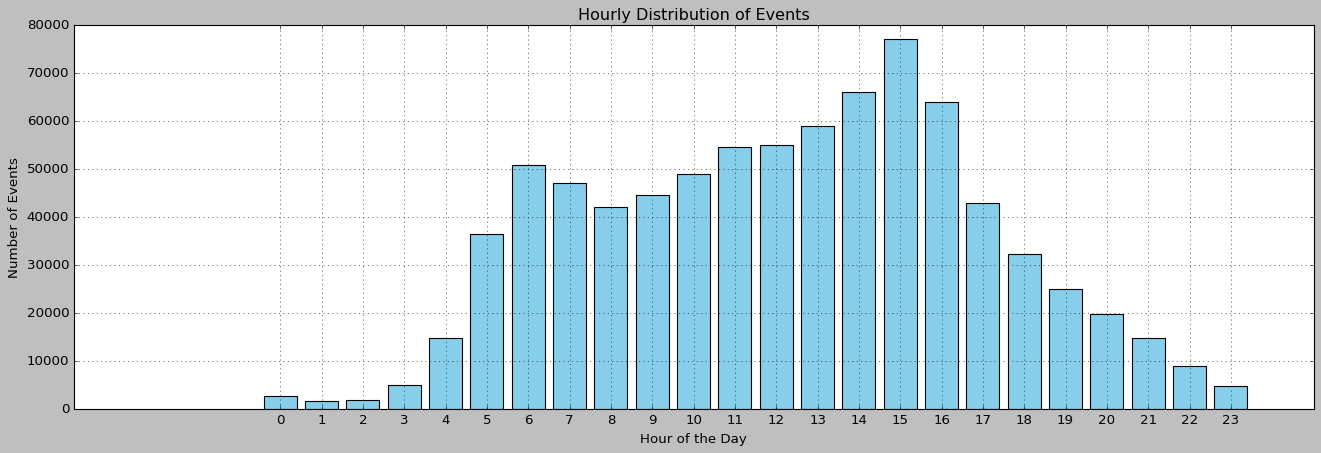

In [79]:
# Plot hourly distribution
plt.figure(figsize=(20, 6))
plt.bar(hourly_counts['hour'], hourly_counts['count'], color='skyblue')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Events')
plt.title('Hourly Distribution of Events')
plt.xticks(range(24))
plt.grid(True)
plt.show()

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


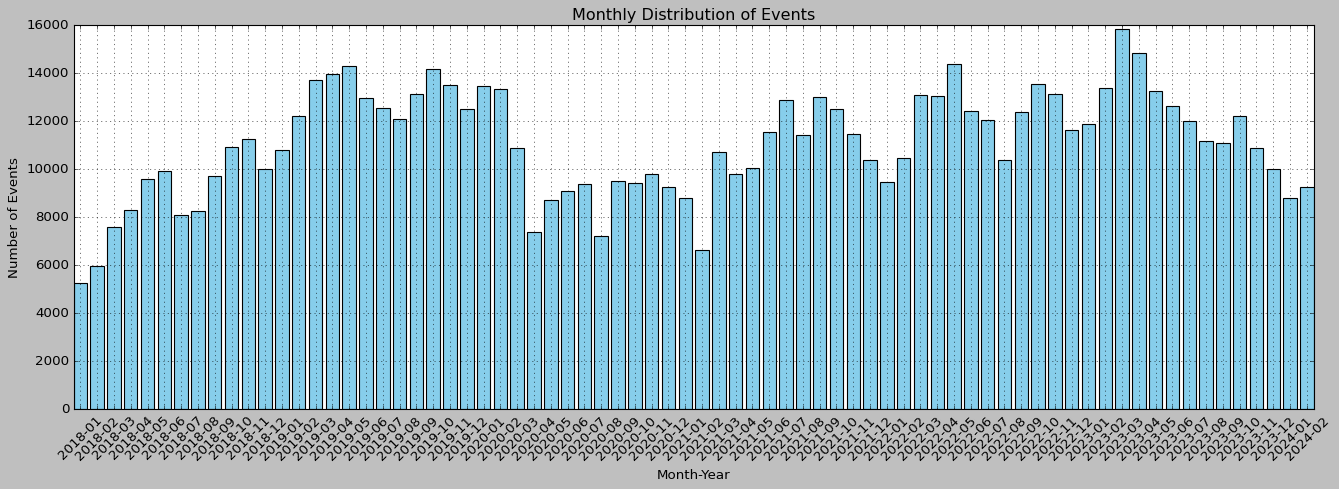

In [80]:
# Plot monthly distribution
plt.figure(figsize=(20, 6))
plt.bar(monthly_counts.apply(lambda x: f"{x['year']}-{x['month']:02d}", axis=1), monthly_counts['count'], color='skyblue')
plt.xlabel('Month-Year')
plt.ylabel('Number of Events')
plt.title('Monthly Distribution of Events')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### What is the average duration of different types of incidents?

In [81]:
get_data = '''SELECT eventid, RTRIM(category), event_start, event_end
              FROM data_lake.safe_driving
              WHERE is_valid = TRUE'''

cursor.execute(get_data)
avg_dur = pd.DataFrame(cursor.fetchall(), columns=['eventid', 'category', 'event_start', 'event_end'])
avg_dur.set_index('eventid', inplace=True)

print(avg_dur.head())

                 category             event_start               event_end
eventid                                                                  
52220043            SPEED 2020-08-25 17:53:33.500 2020-08-25 17:53:40.500
52212688          BRAKING 2020-08-25 07:52:13.300 2020-08-25 07:52:14.200
52455559            SPEED 2020-08-25 15:28:20.000 2020-08-25 15:28:29.000
52655007  HARSH CORNERING 2020-08-25 15:59:00.400 2020-08-25 15:59:02.200
51969578  HARSH CORNERING 2020-08-25 17:04:34.000 2020-08-25 17:04:35.100


          category   duration
0     ACCELERATING   1.584484
1          BRAKING   0.804669
2  HARSH CORNERING   1.762214
3            SPEED  12.668457


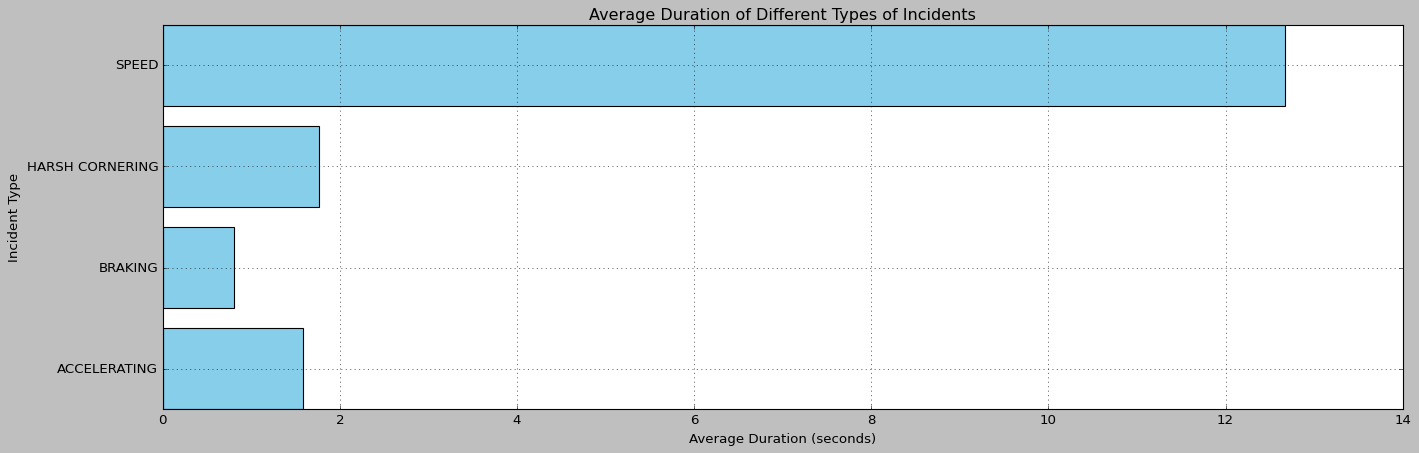

In [82]:
avg_dur['event_start'] = pd.to_datetime(avg_dur['event_start'])
avg_dur['event_end'] = pd.to_datetime(avg_dur['event_end'])

avg_dur['duration'] = (avg_dur['event_end'] - avg_dur['event_start']).dt.total_seconds()

average_duration = avg_dur.groupby('category')['duration'].mean().reset_index()
print(average_duration)

# Plot average durations
plt.figure(figsize=(20, 6))
plt.barh(average_duration['category'], average_duration['duration'], color='skyblue')
plt.xlabel('Average Duration (seconds)')
plt.ylabel('Incident Type')
plt.title('Average Duration of Different Types of Incidents')
plt.grid(True)
plt.show()

## Geographic distribution

In [83]:
get_data = '''SELECT eventid, RTRIM(category), event_start, latitude, longitude, incident_severity, road_name
              FROM data_lake.safe_driving
              WHERE is_valid = TRUE
              AND DATE_TRUNC('year', event_start) = '2023-01-01'
              '''
cursor.execute(get_data)
geo_data = pd.DataFrame(cursor.fetchall(), columns=['eventid', 'category', 'event_start', 'latitude', 'longitude', 'severity', 'road_name'])
geo_data.set_index('eventid', inplace=True)

print(geo_data.head())

                  category             event_start  latitude  longitude severity        road_name
eventid                                                                                          
108229239            SPEED 2023-01-20 15:14:28.500  51.60401   4.726756      SP1   Westerhagelaan
107946216            SPEED 2023-01-20 05:35:11.000  51.59192   4.757573      SP1      Lunetstraat
108248730            SPEED 2023-01-20 15:55:30.000  51.58703   4.722990      SP1       Leursebaan
107349367  HARSH CORNERING 2023-01-20 11:52:55.600  51.60497   4.778563      HC1  Terheijdenseweg
108208826            SPEED 2023-01-20 09:55:48.000  51.60936   4.788150      SP1       Groenedijk


#### Where were speeding events most frequently occurring in 2023?

In [84]:
speed_counts = geo_data[geo_data['category'] == 'SPEED'].groupby(['latitude', 'longitude']).size().reset_index(name='count')

print(speed_counts.sort_values(by='count', ascending=False).head())

       latitude  longitude  count
32333  51.59286    4.74206     21
31806  51.59277    4.74195     21
32378  51.59287    4.74207     20
32075  51.59282    4.74201     19
31961  51.59280    4.74199     19


In [85]:
# Initialize a map centered around an average location
map_center = [geo_data['latitude'].mean(), geo_data['longitude'].mean()]
speed_map = folium.Map(location=map_center, zoom_start=13)

# Add incidents as heatmap
heat_data = [[row['latitude'], row['longitude'], row['count']] for index, row in speed_counts.iterrows()]
HeatMap(heat_data).add_to(speed_map)

# Display the map
speed_map

#### Where were abrupt braking events most frequently occurring in 2023?

In [86]:
brake_counts = geo_data[geo_data['category'] == 'BRAKING'].groupby(['latitude', 'longitude']).size().reset_index(name='count')

print(brake_counts.sort_values(by='count', ascending=False).head())

      latitude  longitude  count
3323  51.60392   4.694113      3
3131  51.60243   4.721648      3
725   51.57541   4.808664      3
1994  51.59407   4.773780      3
1503  51.58744   4.731538      3


In [87]:
# Initialize a map centered around an average location
map_center = [geo_data['latitude'].mean(), geo_data['longitude'].mean()]
brake_map = folium.Map(location=map_center, zoom_start=13)

# Add incidents as heatmap
heat_data = [[row['latitude'], row['longitude'], row['count']] for index, row in brake_counts.iterrows()]
HeatMap(heat_data).add_to(brake_map)

# Display the map
brake_map

#### Where were harsh turning events most frequently occurring in 2023?

In [88]:
turn_counts = geo_data[geo_data['category'] == 'HARSH CORNERING'].groupby(['latitude', 'longitude']).size().reset_index(name='count')

print(turn_counts.sort_values(by='count', ascending=False).head())

       latitude  longitude  count
37433  51.59943    4.74904     36
37643  51.59947    4.74903     33
16598  51.58183    4.82678     30
47997  51.60255    4.72862     29
37396  51.59942    4.74904     28


In [89]:
# Initialize a map centered around an average location
map_center = [geo_data['latitude'].mean(), geo_data['longitude'].mean()]
turn_map = folium.Map(location=map_center, zoom_start=13)

# Add incidents as heatmap
heat_data = [[row['latitude'], row['longitude'], row['count']] for index, row in turn_counts.iterrows()]
HeatMap(heat_data).add_to(turn_map)

# Display the map
turn_map

#### Where were hard acceleration events most frequently occurring in 2023?

In [90]:
acc_counts = geo_data[geo_data['category'] == 'ACCELERATING'].groupby(['latitude', 'longitude']).size().reset_index(name='count')

print(acc_counts.sort_values(by='count', ascending=False).head())

     latitude  longitude  count
100  51.59654    4.77887      3
1    51.56505    4.73750      2
76   51.59080    4.74042      2
54   51.58220    4.82066      2
108  51.59939    4.74806      1


In [91]:
# Initialize a map centered around an average location
map_center = [geo_data['latitude'].mean(), geo_data['longitude'].mean()]
acc_map = folium.Map(location=map_center, zoom_start=13)

# Add incidents as heatmap
heat_data = [[row['latitude'], row['longitude'], row['count']] for index, row in acc_counts.iterrows()]
HeatMap(heat_data).add_to(acc_map)

# Display the map
acc_map

## Incident Severity

#### What are the most common severity levels for each type of incident?

In [24]:
get_level = '''SELECT eventid, RTRIM(category), incident_severity
               FROM data_lake.safe_driving
               WHERE is_valid = TRUE'''

cursor.execute(get_level)
sev_level = pd.DataFrame(cursor.fetchall(), columns=['eventid', 'category', 'incident_severity'])
sev_level.set_index('eventid', inplace=True)

print(sev_level.head())

                 category incident_severity
eventid                                    
51084612  HARSH CORNERING             HC1  
50630123  HARSH CORNERING             HC1  
51125556  HARSH CORNERING             HC1  
51141313            SPEED             SP1  
51503014            SPEED             SP1  


In [25]:
# Group data by incident type and severity level, and count occurrences
severity_counts = sev_level.groupby(['category', 'incident_severity']).size().reset_index(name='count')

# Find the index of the maximum count for each incident type
idx = severity_counts.groupby('category')['count'].idxmax()

# Extract the rows corresponding to the most common severity levels for each incident type
most_common_severity = severity_counts.loc[idx].reset_index(drop=True)

print(most_common_severity)

          category incident_severity   count
0     ACCELERATING             HA1      2682
1          BRAKING             HB1     15487
2  HARSH CORNERING               HC1  200226
3            SPEED             SP1    191153


# KNMI - Weather Dataset

## Weather patterns

#### What are the average temperature, precipitation intensity and wind speeds?

In [26]:
get_data = '''SELECT AVG(RI_REGENM_10)
              FROM data_lake.precipitation'''

cursor.execute(get_data)
results = cursor.fetchall()
print(F"Average Rainfall in mm per hour: {round(results[0][0], 2)}")

get_data = '''SELECT AVG(T_DRYB_10)
              FROM data_lake.temperature'''

cursor.execute(get_data)
results = cursor.fetchall()
print(F"Average Temperature in Degrees C: {round(results[0][0])}")

get_data = '''SELECT AVG(FF_SENSOR_10)
              FROM data_lake.wind'''

cursor.execute(get_data)
results = cursor.fetchall()

print(F"Average windspeed in m/s: {round(results[0][0], 1)}")

Average Rainfall in mm per hour: 0.14
Average Temperature in Degrees C: 11
Average windspeed in m/s: 5.4


#### How do these weather variables change over different times of the day, week, and year?

In [27]:
get_data = '''SELECT p.dtg, p.RI_REGENM_10, t.T_DRYB_10, w.FF_SENSOR_10
              FROM data_lake.precipitation p
              JOIN data_lake.temperature t
              ON p.dtg = t.dtg
              JOIN data_lake.wind w
              ON p.dtg = w.dtg'''

cursor.execute(get_data)
weather_data = pd.DataFrame(cursor.fetchall(), columns=['timestamp', 'rain', 'temperature', 'windspeed'])

print(weather_data.head())

            timestamp  rain  temperature  windspeed
0 2003-04-01 00:10:00   0.0          1.4       0.41
1 2003-04-01 00:20:00   0.0          1.0       1.01
2 2003-04-01 00:30:00   0.0          0.7       1.69
3 2003-04-01 00:40:00   0.0          0.4       1.60
4 2003-04-01 00:50:00   0.0          0.4       1.23


In [28]:
# Extract time components
weather_data['hour'] = weather_data['timestamp'].dt.hour
weather_data['day_of_week'] = weather_data['timestamp'].dt.dayofweek
weather_data['month'] = weather_data['timestamp'].dt.month
weather_data['year'] = weather_data['timestamp'].dt.year

In [29]:
# Calculate average values for each hour of the day
hourly_avg = weather_data.groupby('hour')[['temperature', 'rain', 'windspeed']].mean()

# Calculate average values for each day of the week
daily_avg = weather_data.groupby('day_of_week')[['temperature', 'rain', 'windspeed']].mean()

# Calculate average values for each month
monthly_avg = weather_data.groupby('month')[['temperature', 'rain', 'windspeed']].mean()

# Calculate average values for each year
yearly_avg = weather_data.groupby('year')[['temperature', 'rain', 'windspeed']].mean()

<Figure size 1120x560 with 0 Axes>

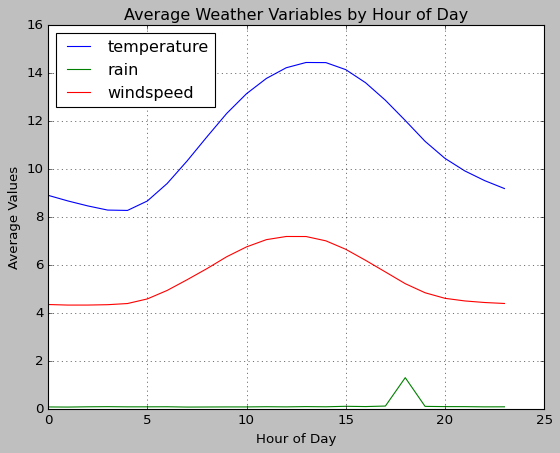

<Figure size 1120x560 with 0 Axes>

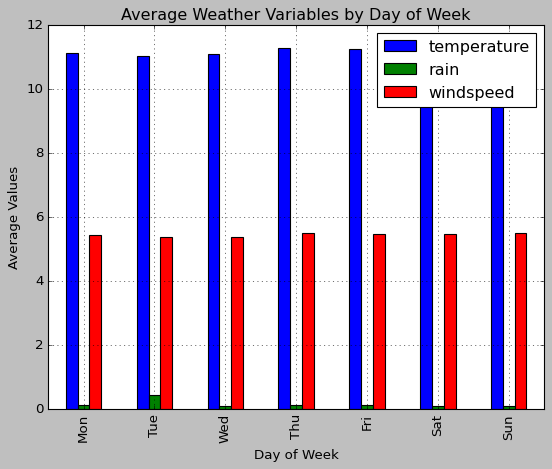

<Figure size 1120x560 with 0 Axes>

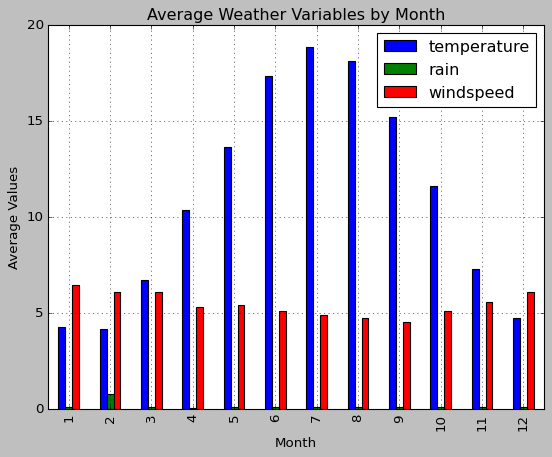

<Figure size 1120x560 with 0 Axes>

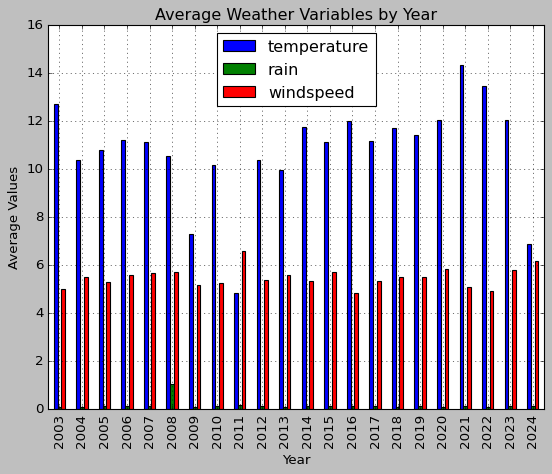

In [30]:
# Plot hourly averages
plt.figure(figsize=(14, 7))
hourly_avg.plot(kind='line')
plt.title('Average Weather Variables by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Values')
plt.grid(True)
plt.show()

# Plot daily averages
plt.figure(figsize=(14, 7))
daily_avg.plot(kind='bar')
plt.title('Average Weather Variables by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Values')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True)
plt.show()

# Plot monthly averages
plt.figure(figsize=(14, 7))
monthly_avg.plot(kind='bar')
plt.title('Average Weather Variables by Month')
plt.xlabel('Month')
plt.ylabel('Average Values')
plt.grid(True)
plt.show()

# Plot yearly averages
plt.figure(figsize=(14, 7))
yearly_avg.plot(kind='bar')
plt.title('Average Weather Variables by Year')
plt.xlabel('Year')
plt.ylabel('Average Values')
plt.grid(True)
plt.show()

## Weather and Incidents Correlation

#### Are there higher event rates during specific weather conditions?

In [45]:
get_data = '''SELECT p.dtg, p.RI_PWS_10, t.T_DRYB_10, w.FF_SENSOR_10, s.category
              FROM data_lake.precipitation p
              LEFT JOIN data_lake.safe_driving s
              ON p.dtg = TO_TIMESTAMP(ROUND(EXTRACT(EPOCH FROM s.event_start) / 600) * 600)
              JOIN data_lake.temperature t
              ON p.dtg = t.dtg
              JOIN data_lake.wind w
              ON p.dtg = w.dtg
              WHERE p.RI_PWS_10 IS NOT NULL
              AND t.T_DRYB_10 IS NOT NULL
              AND w.FF_SENSOR_10 IS NOT NULL'''

cursor.execute(get_data)
data = pd.DataFrame(cursor.fetchall(), columns=['datetime', 'rain', 'temperature', 'wind', 'category'])
data.drop_duplicates(subset='datetime', inplace=True)

print(data.head())

             datetime  rain  temperature  wind category
0 2003-04-01 00:10:00   0.0          1.4  0.41     None
1 2003-04-01 00:20:00   0.0          1.0  1.01     None
2 2003-04-01 00:30:00   0.0          0.7  1.69     None
3 2003-04-01 00:40:00   0.0          0.4  1.60     None
4 2003-04-01 00:50:00   0.0          0.4  1.23     None


In [54]:
# Define thresholds
heavy_rain_threshold = 0.3  # Example threshold for heavy rain in mm/hr
high_wind_speed_threshold = 13.0  # Example threshold for high wind speed in m/s
extreme_temperature_low = 0.0  # Example threshold for low extreme temperature in degrees Celsius
extreme_temperature_high = 30.0  # Example threshold for high extreme temperature in degrees Celsius


In [55]:
# Calculate incident rates for each weather condition
heavy_rain_incidents = data[data['heavy_rain']].shape[0]
high_wind_incidents = data[data['high_wind']].shape[0]
extreme_temp_incidents = data[data['extreme_temp']].shape[0]

# Calculate total incidents
total_incidents = data.shape[0]

print(f'Incidents during heavy rain: {heavy_rain_incidents} ({(heavy_rain_incidents/total_incidents)*100:.2f}%)')
print(f'Incidents during high wind: {high_wind_incidents} ({(high_wind_incidents/total_incidents)*100:.2f}%)')
print(f'Incidents during extreme temperatures: {extreme_temp_incidents} ({(extreme_temp_incidents/total_incidents)*100:.2f}%)')

Incidents during heavy rain: 43781 (4.71%)
Incidents during high wind: 92686 (9.96%)
Incidents during extreme temperatures: 95025 (10.22%)


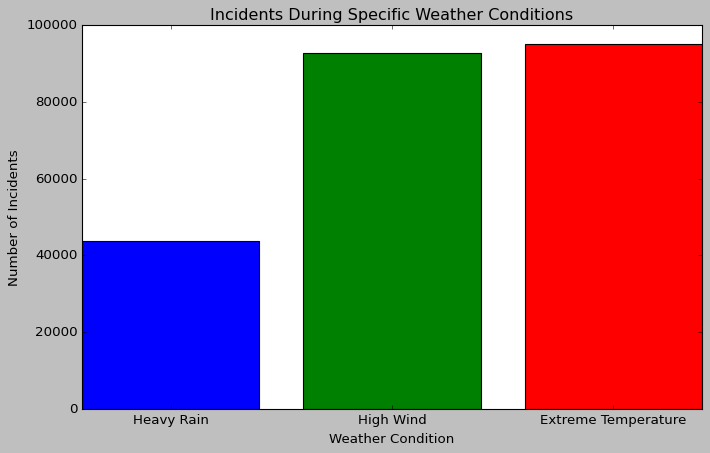

In [56]:
# Prepare data for visualization
conditions = ['Heavy Rain', 'High Wind', 'Extreme Temperature']
incident_counts = [heavy_rain_incidents, high_wind_incidents, extreme_temp_incidents]

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(conditions, incident_counts, color=['blue', 'green', 'red'])
plt.title('Incidents During Specific Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Incidents')
plt.show()

# Accidents dataset

In [43]:
# Read the CSV file in chunks
chunksize = 100000  # Adjust the chunk size based on your memory constraints
chunks = pd.read_csv('./wegvakgeografie_01112023.csv', chunksize=chunksize)
 
# Combine chunks into a DataFrame
accidents = pd.concat(chunks, ignore_index=True)
 
# Convert the 'wvk_begdat' column to datetime format
accidents['wvk_begdat'] = pd.to_datetime(accidents['wvk_begdat'], errors='coerce')
 
# Filter rows where column 16 (index 15) is "Breda" and 'wvk_begdat' is after 2018
accidents_breda = accidents[(accidents.iloc[:, 15] == 'Breda')]
 
# Set display options to show all columns
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Adjust the width to fit more columns
 
# Print the first 5 rows of the filtered DataFrame
print(accidents_breda.head(5))
 
# Print the number of rows in the filtered DataFrame
print(f'Number of rows: {len(accidents_breda)}')

/tmp/ipykernel_23720/3280121527.py:6: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents = pd.concat(chunks, ignore_index=True)
/tmp/ipykernel_23720/3280121527.py:6: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents = pd.concat(chunks, ignore_index=True)
/tmp/ipykernel_23720/3280121527.py:6: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents = pd.concat(chunks, ignore_index=True)
/tmp/ipykernel_23720/3280121527.py:6: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents = pd.concat(chunks, ignore_index=True)
/tmp/ipykernel_23720/3280121527.py:6: DtypeWarning: Columns (35,37) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents = pd.concat(chunks, ignore_index=True)
/tmp/ipykernel_23720/3280121527.py:6: DtypeWarn

                                 FID     wvk_id wvk_begdat wvk_enddat  jte_id_beg  jte_id_end wegbehsrt wegnummer wegdeelltr hectolttr bst_code rpe_code rijrichtng stt_type            stt_naam wpsnaam  gme_id gme_naam  stt_id hnrstrlnks hnrstrrhts  e_hnr_lnks  e_hnr_rhts  l_hnr_lnks  l_hnr_rhts  klok_beg  klok_end sle_type  sle_nummer           fk_veld1       fk_veld5 routeltr  routenr routeltr2  routenr2 routeltr3  routenr3 routeltr4  routenr4 wegnr_hmp  gdb_geomattr_data                                              shape
121  wegvakgeografie_01112023.362676  228202021 2020-12-01        NaN   228202047   228202054         G       NaN          #         #      NaN        #          B        P         Manhuisveld   Breda     758    Breda  162266        NaN        NaN         NaN         NaN         NaN         NaN         3         9      NaN         NaN  22820202120201201  WVK0228202021      NaN      NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN             

In [44]:
print(accidents_breda.columns)

Index(['FID', 'wvk_id', 'wvk_begdat', 'wvk_enddat', 'jte_id_beg', 'jte_id_end', 'wegbehsrt', 'wegnummer', 'wegdeelltr', 'hectolttr', 'bst_code', 'rpe_code', 'rijrichtng', 'stt_type', 'stt_naam', 'wpsnaam', 'gme_id', 'gme_naam', 'stt_id', 'hnrstrlnks', 'hnrstrrhts', 'e_hnr_lnks', 'e_hnr_rhts', 'l_hnr_lnks', 'l_hnr_rhts', 'klok_beg', 'klok_end', 'sle_type', 'sle_nummer', 'fk_veld1', 'fk_veld5', 'routeltr', 'routenr', 'routeltr2', 'routenr2', 'routeltr3', 'routenr3', 'routeltr4', 'routenr4', 'wegnr_hmp', 'gdb_geomattr_data', 'shape'], dtype='object')


## Accident Characteristics

#### What is the distribution of accidents over time?

In [45]:
print(accidents_breda[['wvk_begdat', 'klok_beg']].head())

accidents_breda['c'] = pd.to_datetime(accidents_breda['wvk_begdat']) + pd.to_timedelta(accidents_breda['klok_beg'], unit='h')
print(accidents_breda['datetime_start'].head())

    wvk_begdat  klok_beg
121 2020-12-01         3
538 2020-12-01         9
557 2020-12-01         4
659 2020-12-01         5
661 2020-12-01         4
121   2020-12-01 03:00:00
538   2020-12-01 09:00:00
557   2020-12-01 04:00:00
659   2020-12-01 05:00:00
661   2020-12-01 04:00:00
Name: datetime_start, dtype: datetime64[ns]


/tmp/ipykernel_23720/2665469379.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accidents_breda['datetime_start'] = pd.to_datetime(accidents_breda['wvk_begdat']) + pd.to_timedelta(accidents_breda['klok_beg'], unit='h')


In [46]:
# Extract time components using .loc to avoid SettingWithCopyWarning
accidents_breda.loc[:, 'hour'] = accidents_breda['datetime_start'].dt.hour
accidents_breda.loc[:, 'day_of_week'] = accidents_breda['datetime_start'].dt.dayofweek
accidents_breda.loc[:, 'month'] = accidents_breda['datetime_start'].dt.month
accidents_breda.loc[:, 'year'] = accidents_breda['datetime_start'].dt.year

/tmp/ipykernel_23720/4050011568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accidents_breda.loc[:, 'hour'] = accidents_breda['datetime_start'].dt.hour
/tmp/ipykernel_23720/4050011568.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accidents_breda.loc[:, 'day_of_week'] = accidents_breda['datetime_start'].dt.dayofweek
/tmp/ipykernel_23720/4050011568.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

In [47]:
# Calculate number of incidents per hour
hourly_distribution = accidents_breda['hour'].value_counts().sort_index()

# Calculate number of incidents per day of the week
daily_distribution = accidents_breda['day_of_week'].value_counts().sort_index()

# Calculate number of incidents per month
monthly_distribution = accidents_breda['month'].value_counts().sort_index()

# Calculate number of incidents per year
yearly_distribution = accidents_breda['year'].value_counts().sort_index()


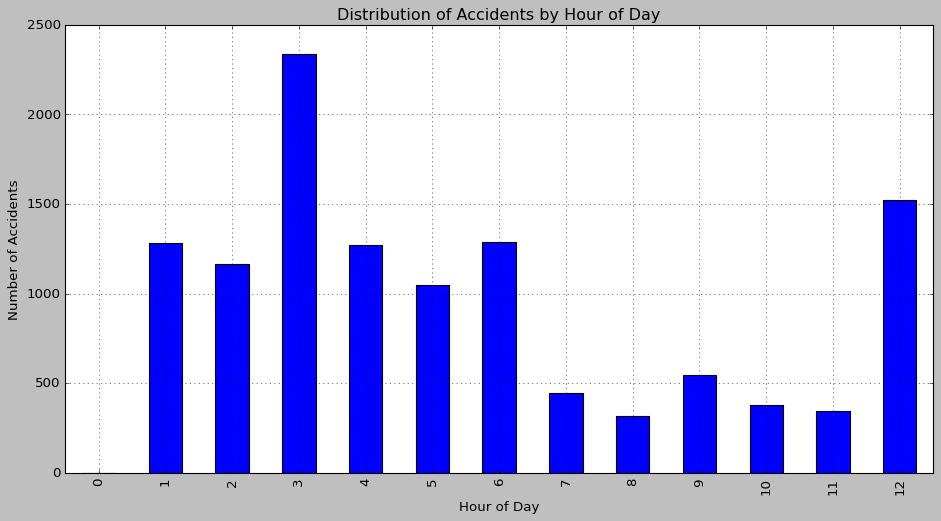

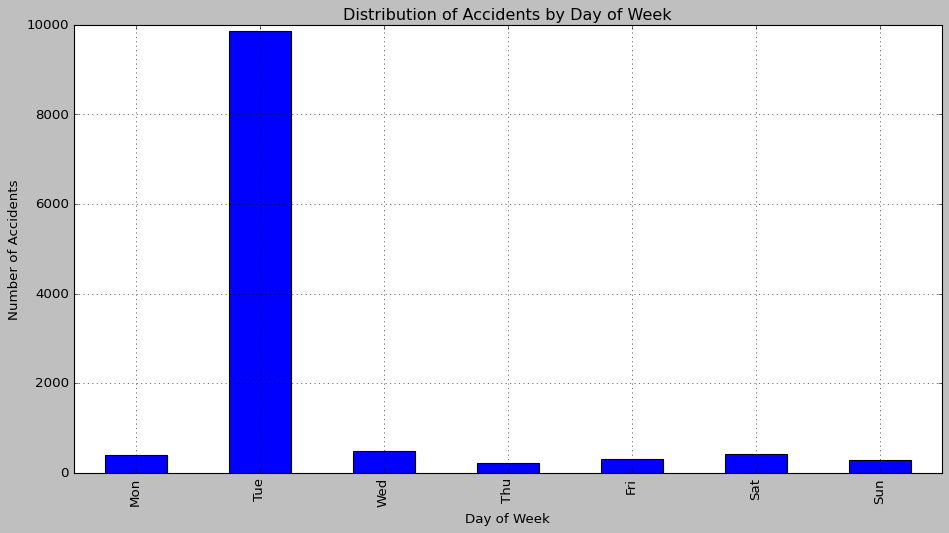

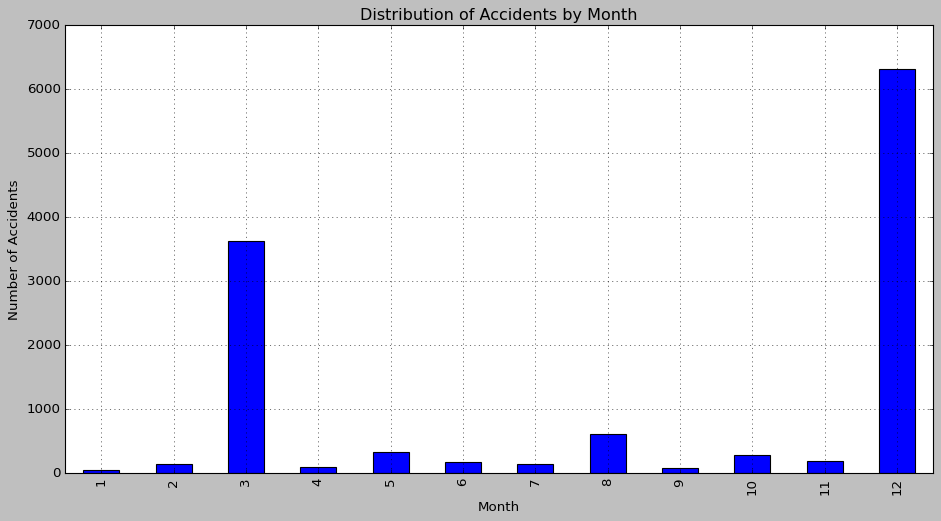

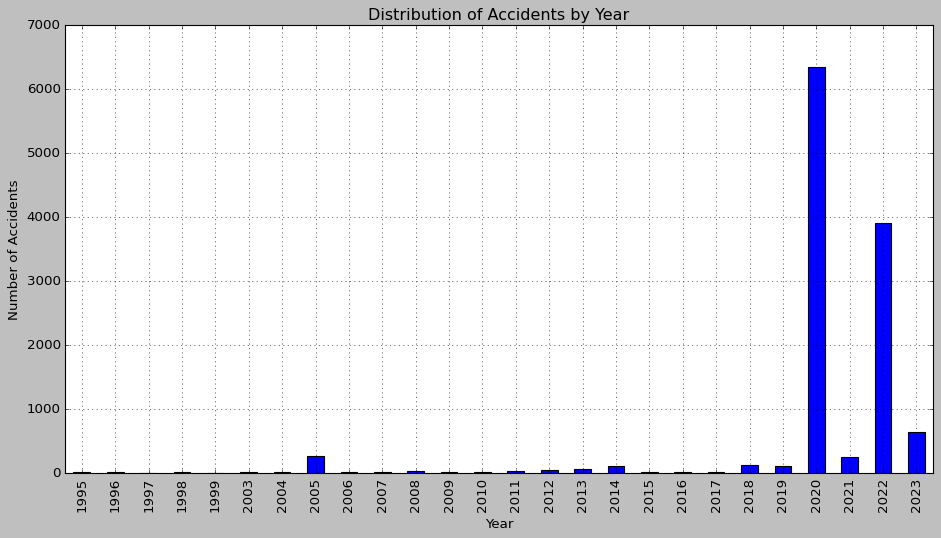

In [48]:
# Plot hourly distribution
plt.figure(figsize=(14, 7))
hourly_distribution.plot(kind='bar')
plt.title('Distribution of Accidents by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

# Plot daily distribution
plt.figure(figsize=(14, 7))
daily_distribution.plot(kind='bar')
plt.title('Distribution of Accidents by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True)
plt.show()

# Plot monthly distribution
plt.figure(figsize=(14, 7))
monthly_distribution.plot(kind='bar')
plt.title('Distribution of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

# Plot yearly distribution
plt.figure(figsize=(14, 7))
yearly_distribution.plot(kind='bar')
plt.title('Distribution of Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

#### Where do most accidents occur?

In [68]:
accidents_breda['datetime_start'].value_counts().head()

datetime_start
2020-12-01 03:00:00    1303
2020-12-01 12:00:00     818
2020-12-01 01:00:00     745
2020-12-01 04:00:00     732
2020-12-01 02:00:00     648
Name: count, dtype: int64

#### IDK

In [ ]:
accidents_breda['

In [60]:
print(accidents_breda[['wvk_id', 'wvk_begdat', 'wvk_enddat', 'stt_type', 'stt_naam', 'klok_beg', 'klok_end']].head())

        wvk_id wvk_begdat wvk_enddat stt_type            stt_naam  klok_beg  klok_end
121  228202021 2020-12-01        NaN        P         Manhuisveld         3         9
538  225199180 2020-12-01        NaN        P          Nonnenveld         9         3
557  220207139 2020-12-01        NaN        P         Bingelkruid         4        10
659  226197060 2020-12-01        NaN        P        Mimosastraat         5        11
661  220197001 2020-12-01        NaN        P  Laan van Mertersem         4         9


# Random ccode

In [111]:
get_data = """SELECT p.dtg, p.RI_PWS_10, t.T_DRYB_10, w.FF_SENSOR_10, RTRIM(s.category), s.incident_severity
              FROM data_lake.precipitation p
              LEFT JOIN data_lake.safe_driving s
              ON p.dtg = TO_TIMESTAMP(ROUND(EXTRACT(EPOCH FROM s.event_start) / 600) * 600)
              JOIN data_lake.temperature t
              ON p.dtg = t.dtg
              JOIN data_lake.wind w
              ON p.dtg = w.dtg
              WHERE p.RI_PWS_10 IS NOT NULL
              AND t.T_DRYB_10 IS NOT NULL
              AND w.FF_SENSOR_10 IS NOT NULL
              AND p.dtg > '2018-01-01'"""

cursor.execute(get_data)
data = pd.DataFrame(cursor.fetchall(), columns=['datetime', 'rain', 'temperature', 'wind', 'category', 'severity'])
data.drop_duplicates(subset='datetime', inplace=True)

print(data.head())

             datetime    rain  temperature   wind         category severity
0 2018-01-01 00:10:00  0.0000          8.9  13.83             None     None
1 2018-01-01 00:20:00  0.0000          8.8  12.87  HARSH CORNERING    HC1  
6 2018-01-01 00:30:00  0.0000          8.8  13.48  HARSH CORNERING    HC1  
8 2018-01-01 00:40:00  0.0447          8.7  12.97             None     None
9 2018-01-01 00:50:00  0.0062          8.7  12.93            SPEED    SP1  


In [112]:
print(data['category'].value_counts())

category
HARSH CORNERING    87112
SPEED              76977
BRAKING             9091
ACCELERATING        4903
Name: count, dtype: int64


In [113]:
pd.set_option("display.max_rows", None)